In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("orders.csv")

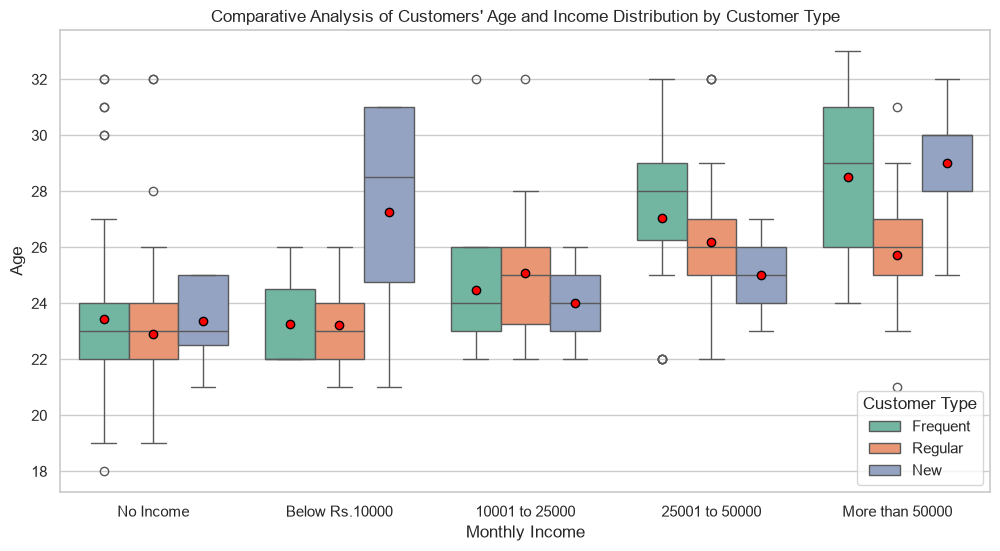

In [3]:

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

income_order = [
    "No Income",
    "Below Rs.10000",
    "10001 to 25000",
    "25001 to 50000",
    "More than 50000",
]

# Boxplot and Stripplot
ax = sns.boxplot(
    x="Monthly Income",
    y="Age",
    hue="Customer Type",
    data=df,
    palette="Set2",
    showmeans=True,
    order = income_order,
    meanprops={
        "marker": "o",
        "markerfacecolor": "red",
        "markeredgecolor": "black",
    },
)
plt.title("Comparative Analysis of Customers' Age and Income Distribution by Customer Type")

plt.xlabel("Monthly Income")

plt.ylabel("Age")

plt.legend(title="Customer Type")

plt.show()


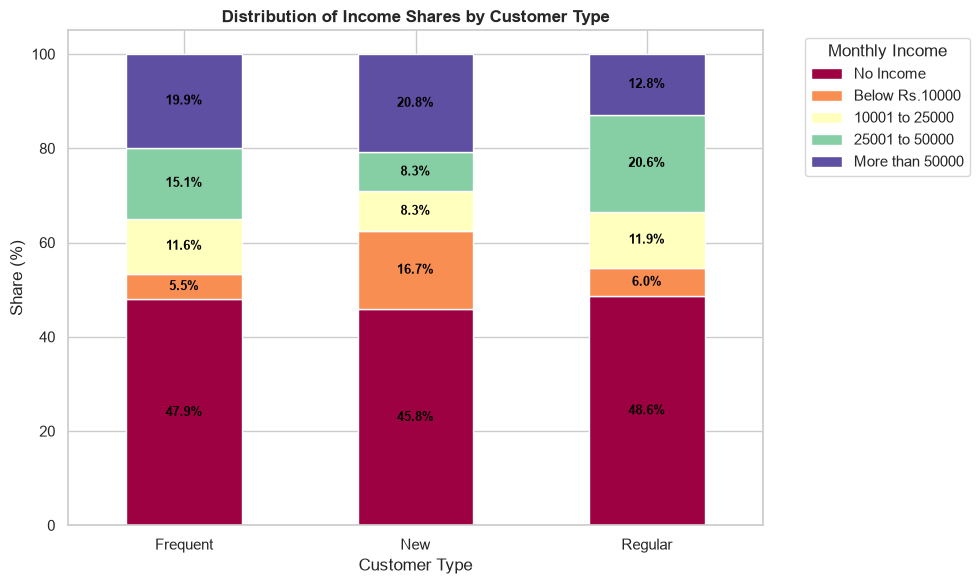

In [4]:

ct = pd.crosstab(df["Customer Type"], df["Monthly Income"], normalize="index") * 100
ct = ct[income_order]

# 2. Draw stacked bar chart
ax = ct.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Spectral")

plt.title(
    "Distribution of Income Shares by Customer Type",
    fontsize=12,
    weight="bold",
)
plt.xlabel("Customer Type")
plt.ylabel("Share (%)")
plt.legend(title="Monthly Income", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)

# Add data labels
for p in ax.patches:
  width, height = p.get_width(), p.get_height()
  if height > 5:  # Avoid adding labels to small shares
    ax.annotate(
        f"{height:.1f}%",
        (p.get_x() + width / 2.0, p.get_y() + height / 2.0),
        ha="center",
        va="center",
        color="black",
        fontsize=9,
        weight="bold",
    )

plt.tight_layout()
plt.show()


In [5]:
# Ta'lim va Kasb bo'yicha Fikrlar (Reviews) jadvali
review_table = pd.crosstab(
    [df["Educational Qualifications"], df["Occupation"]],
    df["Feedback"],
    margins=True,
)
review_table

Feedback                                   Negative   Positive  All
Educational Qualifications Occupation                              
Graduate                   Employee               22        46   68
                           House wife              1         2    3
                           Self Employeed          7        22   29
                           Student                12        65   77
Ph.D                       Employee                3         9   12
                           Self Employeed          1         2    3
                           Student                 1         7    8
Post Graduate              Employee                8        30   38
                           Self Employeed          4        10   14
                           Student                 8       114  122
School                     House wife              0         5    5
                           Self Employeed          3         4    7
Uneducated                 House wife              0         1    1
                           Self Employeed          1         0    1
All                                               71       317  388